In [1]:
import pandas as pd
import numpy as np
import glob
import os

In [2]:
all_times_df = pd.read_csv("../../data/archived_feeds.txt")
all_times_df = all_times_df.drop(['archive_note'], axis=1)
all_times_df['feed_start_date'] = pd.to_datetime(all_times_df['feed_start_date'], format='%Y%m%d')
all_times_df['feed_end_date'] = pd.to_datetime(all_times_df['feed_end_date'], format='%Y%m%d')
all_times_df

,feed_start_date,feed_end_date,feed_version,archive_url
0,2026-03-28,2026-06-13,"Spring 2026, 2026-04-04T23:34:29+00:00, version D",https://cdn.mbtace.com/archive/20260328.zip
1,2026-03-27,2026-03-27,"Spring 2026, 2026-04-03T18:45:06+00:00, version D",https://cdn.mbtace.com/archive/20260327.zip
2,2026-03-23,2026-03-26,"Spring 2026, 2026-03-30T21:02:11+00:00, version D",https://cdn.mbtace.com/archive/20260323.zip
3,2026-03-20,2026-03-22,"Spring 2026, 2026-03-27T18:55:10+00:00, version D",https://cdn.mbtace.com/archive/20260320.zip
4,2026-03-19,2026-03-19,"Spring 2026, 2026-03-26T22:58:34+00:00, version D",https://cdn.mbtace.com/archive/20260319.zip
...,...,...,...,...
948,2009-05-15,2009-05-28,"GTFS file for Google Transit, published 5/15/09",https://cdn.mbtace.com/archive/20090515.zip
949,2009-04-24,2009-05-14,"GTFS file for Google Transit, published 4/24/09",https://cdn.mbtace.com/archive/20090424.zip
950,2009-04-09,2009-04-23,"GTFS file for Google Transit, published 4/9/09",https://cdn.mbtace.com/archive/20090409.zip
951,2009-04-03,2009-04-08,"GTFS file for Google Transit, published 4/3/09",https://cdn.mbtace.com/archive/20090403.zip


In [3]:
time_schedule_df = pd.read_csv("2022_stop_times.csv")
time_schedule_df['stops_start_date'] = pd.to_datetime(time_schedule_df['stops_start_date'])

# merge to get the valid start and end date of the stop times information
final_time_schedule_df = time_schedule_df.merge(
    all_times_df[["feed_start_date", "feed_end_date"]],
    left_on="stops_start_date",
    right_on="feed_start_date",
    how="left"
)
final_time_schedule_df = final_time_schedule_df.drop(["stops_start_date"], axis=1)
final_time_schedule_df

/var/folders/z7/152736054bv0sl_wm9ygspfr0000gn/T/ipykernel_10497/1893649878.py:1: DtypeWarning: Columns (0: trip_id, 1: stop_id) have mixed types. Specify dtype option on import or set low_memory=False.
  time_schedule_df = pd.read_csv("2022_stop_times.csv")


,trip_id,arrival_time,departure_time,stop_id,stop_sequence,feed_start_date,feed_end_date
0,50890494,05:16:00,05:16:00,70094,50,2022-04-22,2022-04-25
1,50890494,05:18:00,05:18:00,70092,60,2022-04-22,2022-04-25
2,50890494,05:20:00,05:20:00,70090,70,2022-04-22,2022-04-25
3,50890494,05:22:00,05:22:00,70088,80,2022-04-22,2022-04-25
4,50890494,05:24:00,05:24:00,70086,90,2022-04-22,2022-04-25
...,...,...,...,...,...,...,...
23983221,53257647,06:25:00,06:25:00,635,24,2022-08-16,2022-08-16
23983222,53257647,06:26:00,06:26:00,636,25,2022-08-16,2022-08-16
23983223,53257647,06:27:00,06:27:00,637,26,2022-08-16,2022-08-16
23983224,53257647,06:27:00,06:27:00,638,27,2022-08-16,2022-08-16


In [ ]:
# GETTING ALL EVENTS DATA
df_list = []
for i in range(1, 3):
    dir = glob.glob(f'../../data/202{i}/*.csv')
    for month_csv_file in dir:
        month_csv_file_df = pd.read_csv(month_csv_file)
        
        df_list.append(month_csv_file_df)
print(len(df_list))
final_events_df = pd.concat(df_list, ignore_index=True)
final_events_df

/var/folders/z7/152736054bv0sl_wm9ygspfr0000gn/T/ipykernel_10497/3732691352.py:6: DtypeWarning: Columns (0: vehicle_label) have mixed types. Specify dtype option on import or set low_memory=False.
  month_csv_file_df = pd.read_csv(month_csv_file)


12


,service_date,route_id,trip_id,direction_id,stop_id,stop_sequence,vehicle_id,vehicle_label,event_type,event_time,event_time_sec
0,2022-07-01,Red,52370898,0,70061,1,R-547147BD,1882.0,ARR,1656736332,88332
1,2022-07-01,Red,52370898,0,70061,1,R-547147BD,1860.0,DEP,1656736536,88536
2,2022-07-01,Red,52370898,0,70063,10,R-547147BD,1860.0,ARR,1656736791,88791
3,2022-07-01,Red,52370898,0,70063,10,R-547147BD,1860.0,DEP,1656736833,88833
4,2022-07-01,Red,52370898,0,70065,20,R-547147BD,1860.0,ARR,1656736903,88903
...,...,...,...,...,...,...,...,...,...,...,...
9279481,2022-10-31,Blue,NONREV-1580463478,0,70055,20,B-54734D3B,715.0,ARR,1667266882,78082
9279482,2022-10-31,Blue,NONREV-1580463478,0,70059,1,B-54734D3B,715.0,DEP,1667266739,77939
9279483,2022-10-31,Blue,NONREV-1580463478,0,70057,10,B-54734D3B,715.0,ARR,1667266775,77975
9279484,2022-10-31,Blue,NONREV-1580463478,0,70057,10,B-54734D3B,715.0,DEP,1667266813,78013


In [ ]:
# dropping unnecessary cols
new_final_events_df = final_events_df.drop(["vehicle_id", "vehicle_label", "direction_id"], axis = 1)
new_final_events_df = new_final_events_df.dropna()

# Convert to datetime objects - preprocessing work
new_final_events_df['service_date'] = pd.to_datetime(new_final_events_df['service_date']).astype('datetime64[ns]')
final_time_schedule_df['feed_start_date'] = pd.to_datetime(final_time_schedule_df['feed_start_date']).astype('datetime64[ns]')
final_time_schedule_df['feed_end_date'] = pd.to_datetime(final_time_schedule_df['feed_end_date']).astype('datetime64[ns]')

new_final_events_df["trip_id"] = new_final_events_df["trip_id"].astype(str)
final_time_schedule_df["trip_id"] = final_time_schedule_df["trip_id"].astype(str)

new_final_events_df["stop_id"] = new_final_events_df["stop_id"].astype(str)
final_time_schedule_df["stop_id"] = final_time_schedule_df["stop_id"].astype(str)

new_final_events_df = new_final_events_df.sort_values('service_date')
final_time_schedule_df = final_time_schedule_df.sort_values('feed_start_date')

In [7]:
merged_df = pd.merge_asof(
    new_final_events_df,
    final_time_schedule_df,
    left_on="service_date",
    right_on="feed_start_date",
    by=["trip_id", "stop_id", "stop_sequence"],                  
    direction="backward"                                             # get most recent feed_start_date <= service_date
)
merged_df = merged_df.dropna()

In [ ]:
merged_df['departure_time_sec'] = merged_df['departure_time'].apply(lambda x: sum(int(i) * 60**(2 - idx) for idx, i in enumerate(x.split(':'))))
merged_df['arrival_time_sec'] = merged_df['arrival_time'].apply(lambda x: sum(int(i) * 60**(2 - idx) for idx, i in enumerate(x.split(':'))))
merged_df

In [19]:
# add delay column
merged_df['delay_sec'] = np.where(
    merged_df['event_type'] == 'ARR',
    merged_df['event_time_sec'] - merged_df['arrival_time_sec'],
    merged_df['event_time_sec'] - merged_df['departure_time_sec']
)

# Convert to minutes to make it more human readable
merged_df['delay_min'] = merged_df['delay_sec'] / 60

merged_df['hour'] = merged_df['arrival_time_sec'] // 3600
merged_df['day_of_week'] = pd.to_datetime(merged_df['service_date']).dt.day_name()
merged_df.to_csv("../../data/2022_data.csv")



In [10]:
# look at time buckets (every 5 min) for grouping events and looking at the delays for a specific stop_id and arrival/departure time across multiple days
merged_df['time_bucket'] = (merged_df['arrival_time_sec'] // 300) * 300
arrival_merged_df= merged_df[merged_df['event_type'] == 'ARR']
arrival_merged_df


,service_date,route_id,trip_id,stop_id,stop_sequence,event_type,event_time,event_time_sec,arrival_time,departure_time,feed_start_date,feed_end_date,departure_time_sec,arrival_time_sec,delay_sec,delay_min,time_bucket
1538769,2022-02-23,Blue,50445039,70045,70,ARR,1645650880,58480,16:16:00,16:16:00,2022-02-23,2022-02-27,58560,58560,-80,-1.333333,58500
1538770,2022-02-23,Blue,50445039,70838,110,ARR,1645651331,58931,16:21:00,16:21:00,2022-02-23,2022-02-27,58860,58860,71,1.183333,58800
1538772,2022-02-23,Blue,50445039,70053,30,ARR,1645650437,58037,16:07:00,16:07:00,2022-02-23,2022-02-27,58020,58020,17,0.283333,57900
1538773,2022-02-23,Blue,50445039,70055,20,ARR,1645650343,57943,16:06:00,16:06:00,2022-02-23,2022-02-27,57960,57960,-17,-0.283333,57900
1538777,2022-02-23,Blue,50445039,70051,40,ARR,1645650520,58120,16:09:00,16:09:00,2022-02-23,2022-02-27,58140,58140,-20,-0.333333,57900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8944874,2022-12-17,Orange,52721222,70001,1,ARR,1671321424,68224,19:05:00,19:05:00,2022-11-28,2022-11-30,68700,68700,-476,-7.933333,68700
8944902,2022-12-17,Orange,52721225,70001,1,ARR,1671323320,70120,19:34:00,19:34:00,2022-11-28,2022-11-30,70440,70440,-320,-5.333333,70200
8944974,2022-12-17,Orange,52721218,70001,1,ARR,1671318781,65581,18:26:00,18:26:00,2022-11-28,2022-11-30,66360,66360,-779,-12.983333,66300
8944991,2022-12-17,Orange,52721220,70001,1,ARR,1671320194,66994,18:45:00,18:45:00,2022-11-28,2022-11-30,67500,67500,-506,-8.433333,67500


In [ ]:
# adding an hour and a day column to try and identify delay patterns on the days of the week or hour of the day
arrival_merged_df['hour'] = arrival_merged_df['arrival_time_sec'] // 3600
arrival_merged_df['day_of_week'] = pd.to_datetime(arrival_merged_df['service_date']).dt.day_name()
arrival_merged_df

,service_date,route_id,trip_id,stop_id,stop_sequence,event_type,event_time,event_time_sec,arrival_time,departure_time,feed_start_date,feed_end_date,departure_time_sec,arrival_time_sec,delay_sec,delay_min,time_bucket,hour,day_of_week
1538769,2022-02-23,Blue,50445039,70045,70,ARR,1645650880,58480,16:16:00,16:16:00,2022-02-23,2022-02-27,58560,58560,-80,-1.333333,58500,16,Wednesday
1538770,2022-02-23,Blue,50445039,70838,110,ARR,1645651331,58931,16:21:00,16:21:00,2022-02-23,2022-02-27,58860,58860,71,1.183333,58800,16,Wednesday
1538772,2022-02-23,Blue,50445039,70053,30,ARR,1645650437,58037,16:07:00,16:07:00,2022-02-23,2022-02-27,58020,58020,17,0.283333,57900,16,Wednesday
1538773,2022-02-23,Blue,50445039,70055,20,ARR,1645650343,57943,16:06:00,16:06:00,2022-02-23,2022-02-27,57960,57960,-17,-0.283333,57900,16,Wednesday
1538777,2022-02-23,Blue,50445039,70051,40,ARR,1645650520,58120,16:09:00,16:09:00,2022-02-23,2022-02-27,58140,58140,-20,-0.333333,57900,16,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8944874,2022-12-17,Orange,52721222,70001,1,ARR,1671321424,68224,19:05:00,19:05:00,2022-11-28,2022-11-30,68700,68700,-476,-7.933333,68700,19,Saturday
8944902,2022-12-17,Orange,52721225,70001,1,ARR,1671323320,70120,19:34:00,19:34:00,2022-11-28,2022-11-30,70440,70440,-320,-5.333333,70200,19,Saturday
8944974,2022-12-17,Orange,52721218,70001,1,ARR,1671318781,65581,18:26:00,18:26:00,2022-11-28,2022-11-30,66360,66360,-779,-12.983333,66300,18,Saturday
8944991,2022-12-17,Orange,52721220,70001,1,ARR,1671320194,66994,18:45:00,18:45:00,2022-11-28,2022-11-30,67500,67500,-506,-8.433333,67500,18,Saturday


In [12]:
stop_df = arrival_merged_df[arrival_merged_df['stop_id'] == '70055'] # example stop id

stop_df = stop_df.reset_index()

# averaging the delay values for each day of the week across the hours to see if there are any delay trends on specific days of the week
arr_pivot = stop_df.pivot_table(
    index='hour',
    columns='day_of_week',
    values='delay_min',
    aggfunc='mean'   
)

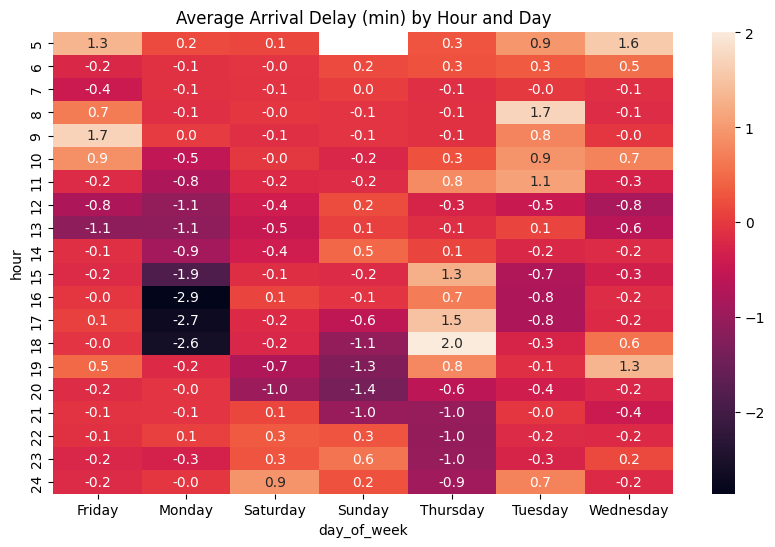

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(arr_pivot, annot=True, fmt=".1f")
plt.title("Average Arrival Delay (min) by Hour and Day")
plt.show()

In [14]:
# look at time buckets (every 5 min) for grouping events and looking at the delays for a specific stop_id and arrival/departure time across multiple days
merged_df['time_bucket'] = (merged_df['departure_time_sec'] // 300) * 300
departure_merged_df= merged_df[merged_df['event_type'] == 'DEP']
departure_merged_df

,service_date,route_id,trip_id,stop_id,stop_sequence,event_type,event_time,event_time_sec,arrival_time,departure_time,feed_start_date,feed_end_date,departure_time_sec,arrival_time_sec,delay_sec,delay_min,time_bucket
1538771,2022-02-23,Blue,50445039,70039,100,DEP,1645651288,58888,16:20:00,16:20:00,2022-02-23,2022-02-27,58800,58800,88,1.466667,58800
1538774,2022-02-23,Blue,50445039,70053,30,DEP,1645650469,58069,16:07:00,16:07:00,2022-02-23,2022-02-27,58020,58020,49,0.816667,57900
1538775,2022-02-23,Blue,50445039,70045,70,DEP,1645650932,58532,16:16:00,16:16:00,2022-02-23,2022-02-27,58560,58560,-28,-0.466667,58500
1538776,2022-02-23,Blue,50445039,70057,10,DEP,1645650273,57873,16:04:00,16:04:00,2022-02-23,2022-02-27,57840,57840,33,0.550000,57600
1538779,2022-02-23,Blue,50445039,70055,20,DEP,1645650391,57991,16:06:00,16:06:00,2022-02-23,2022-02-27,57960,57960,31,0.516667,57900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8944932,2022-12-17,Orange,52721225,70001,1,DEP,1671323901,70701,19:34:00,19:34:00,2022-11-28,2022-11-30,70440,70440,261,4.350000,70200
8945006,2022-12-17,Orange,52721218,70001,1,DEP,1671319891,66691,18:26:00,18:26:00,2022-11-28,2022-11-30,66360,66360,331,5.516667,66300
8945061,2022-12-17,Orange,52721222,70001,1,DEP,1671321929,68729,19:05:00,19:05:00,2022-11-28,2022-11-30,68700,68700,29,0.483333,68700
8945084,2022-12-17,Orange,52721220,70001,1,DEP,1671320775,67575,18:45:00,18:45:00,2022-11-28,2022-11-30,67500,67500,75,1.250000,67500


In [15]:
# grouping to see if there are changes in time of day
departure_merged_df['hour'] = departure_merged_df['arrival_time_sec'] // 3600
departure_merged_df['day_of_week'] = pd.to_datetime(departure_merged_df['service_date']).dt.day_name()
departure_merged_df

,service_date,route_id,trip_id,stop_id,stop_sequence,event_type,event_time,event_time_sec,arrival_time,departure_time,feed_start_date,feed_end_date,departure_time_sec,arrival_time_sec,delay_sec,delay_min,time_bucket,hour,day_of_week
1538771,2022-02-23,Blue,50445039,70039,100,DEP,1645651288,58888,16:20:00,16:20:00,2022-02-23,2022-02-27,58800,58800,88,1.466667,58800,16,Wednesday
1538774,2022-02-23,Blue,50445039,70053,30,DEP,1645650469,58069,16:07:00,16:07:00,2022-02-23,2022-02-27,58020,58020,49,0.816667,57900,16,Wednesday
1538775,2022-02-23,Blue,50445039,70045,70,DEP,1645650932,58532,16:16:00,16:16:00,2022-02-23,2022-02-27,58560,58560,-28,-0.466667,58500,16,Wednesday
1538776,2022-02-23,Blue,50445039,70057,10,DEP,1645650273,57873,16:04:00,16:04:00,2022-02-23,2022-02-27,57840,57840,33,0.550000,57600,16,Wednesday
1538779,2022-02-23,Blue,50445039,70055,20,DEP,1645650391,57991,16:06:00,16:06:00,2022-02-23,2022-02-27,57960,57960,31,0.516667,57900,16,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8944932,2022-12-17,Orange,52721225,70001,1,DEP,1671323901,70701,19:34:00,19:34:00,2022-11-28,2022-11-30,70440,70440,261,4.350000,70200,19,Saturday
8945006,2022-12-17,Orange,52721218,70001,1,DEP,1671319891,66691,18:26:00,18:26:00,2022-11-28,2022-11-30,66360,66360,331,5.516667,66300,18,Saturday
8945061,2022-12-17,Orange,52721222,70001,1,DEP,1671321929,68729,19:05:00,19:05:00,2022-11-28,2022-11-30,68700,68700,29,0.483333,68700,19,Saturday
8945084,2022-12-17,Orange,52721220,70001,1,DEP,1671320775,67575,18:45:00,18:45:00,2022-11-28,2022-11-30,67500,67500,75,1.250000,67500,18,Saturday


In [16]:
stop_df = departure_merged_df[departure_merged_df['stop_id'] == '70053'] # example stop id

stop_df = stop_df.reset_index()

# averaging the delay values for each day of the week across the hours to see if there are any delay trends on specific days of the week
dep_pivot = stop_df.pivot_table(
    index='hour',
    columns='day_of_week',
    values='delay_min',
    aggfunc='mean'   
)

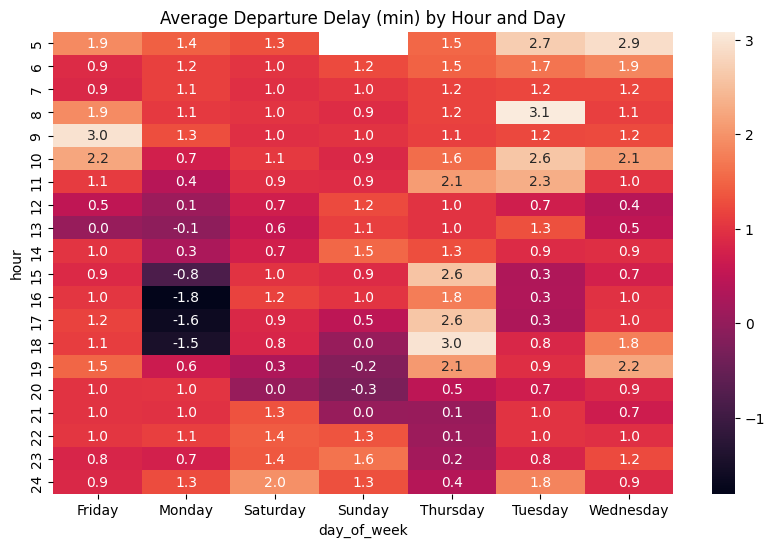

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(dep_pivot, annot=True, fmt=".1f")
plt.title("Average Departure Delay (min) by Hour and Day")
plt.show()